In [ ]:
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify lightgbm xgboost catboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

print ("ok")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
ok


In [ ]:
bbox = (30.18, 59.86, 30.55, 60.03)
polygon_wgs = box(*bbox)

G = ox.graph_from_polygon(polygon_wgs, network_type="drive", simplify=True, retain_all=False)
nodes, edges = ox.graph_to_gdfs(G)

edges_m = edges.to_crs("EPSG:32636")

print(f"Загружено рёбер: {len(edges_m)}")
edges_m.head()

Загружено рёбер: 16188


osmid       highway lanes  maxspeed  \
u      v          key                                                          
219808 2327840    0                   33997807  primary_link     2  RU:urban   
       389449562  0                  201380605       primary     3  RU:urban   
219811 1832085962 0                   33997784  primary_link     2  RU:urban   
       1465050831 0    [1123339577, 178581714]       primary     3  RU:urban   
219812 249890545  0                    4459876       primary     2  RU:urban   

                       oneway reversed      length                       name  \
u      v          key                                                           
219808 2327840    0     False    False   26.026139                        NaN   
       389449562  0      True    False   31.504625         Лиговский проспект   
219811 1832085962 0     False    False   27.905147                        NaN   
       1465050831 0      True    False  394.654005         Лиговский проспект   
219812 249890545  0      True    False   33.758153  Воздухоплавательная улица   

                                                                geometry  \
u      v          key                                                      
219808 2327840    0    LINESTRING (350708.451 6642736.478, 350691.058...   
       389449562  0    LINESTRING (350708.451 6642736.478, 350731.745...   
219811 1832085962 0    LINESTRING (351066.086 6643191.309, 351091.28 ...   
       1465050831 0    LINESTRING (351066.086 6643191.309, 351049.439...   
219812 249890545  0    LINESTRING (351193.111 6643457.124, 351207.112...   

                      bridge junction  ref width tunnel access  
u      v          key                                           
219808 2327840    0      NaN      NaN  NaN   NaN    NaN    NaN  
       389449562  0      NaN      NaN  NaN   NaN    NaN    NaN  
219811 1832085962 0      NaN      NaN  NaN   NaN    NaN    NaN  
       1465050831 0      NaN      NaN  NaN   NaN    NaN    NaN  
219812 249890545  0      NaN      NaN  NaN   NaN    NaN    NaN

In [ ]:
roads = edges_m.copy()

roads["length_m_geom"] = roads.geometry.length
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return np.arctan2(y2 - y1, x2 - x1)

roads["angle_rad"] = roads.geometry.apply(segment_angle)

roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,16188.000000,16188.000000,16188.000000,16188.000000
mean,183.493683,177.098529,1.045255,0.002287
std,243.708214,228.278203,0.896425,1.818755
min,1.236514,0.000000,1.000000,-3.141433
25%,28.190656,27.409482,1.000000,-1.582503
50%,106.620542,104.564517,1.000018,0.000000
75%,249.094575,243.518460,1.002710,1.554487
max,6640.370574,5357.940848,76.797540,3.140873


In [ ]:
roads["highway_str"] = roads["highway"].apply(lambda x: ",".join(x) if isinstance(x, list) else str(x))
highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")
roads = pd.concat([roads, highway_dummies], axis=1)
highway_dummies.head()

highway_living_street  \
u      v          key                          
219808 2327840    0                    False   
       389449562  0                    False   
219811 1832085962 0                    False   
       1465050831 0                    False   
219812 249890545  0                    False   

                       highway_living_street,residential  \
u      v          key                                      
219808 2327840    0                                False   
       389449562  0                                False   
219811 1832085962 0                                False   
       1465050831 0                                False   
219812 249890545  0                                False   

                       highway_living_street,unclassified  highway_motorway  \
u      v          key                                                         
219808 2327840    0                                 False             False   
       389449562  0                                 False             False   
219811 1832085962 0                                 False             False   
       1465050831 0                                 False             False   
219812 249890545  0                                 False             False   

                       highway_primary  highway_primary_link  \
u      v          key                                          
219808 2327840    0              False                  True   
       389449562  0               True                 False   
219811 1832085962 0              False                  True   
       1465050831 0               True                 False   
219812 249890545  0               True                 False   

                       highway_primary_link,primary  \
u      v          key                                 
219808 2327840    0                           False   
       389449562  0                           False   
219811 1832085962 0                           False   
       1465050831 0                           False   
219812 249890545  0                           False   

                       highway_primary_link,residential  highway_residential  \
u      v          key                                                          
219808 2327840    0                               False                False   
       389449562  0                               False                False   
219811 1832085962 0                               False                False   
       1465050831 0                               False                False   
219812 249890545  0                               False                False   

                       highway_road  ...  highway_secondary_link,secondary  \
u      v          key                ...                                     
219808 2327840    0           False  ...                             False   
       389449562  0           False  ...                             False   
219811 1832085962 0           False  ...                             False   
       1465050831 0           False  ...                             False   
219812 249890545  0           False  ...                             False   

                       highway_tertiary  highway_tertiary,residential  \
u      v          key                                                   
219808 2327840    0               False                         False   
       389449562  0               False                         False   
219811 1832085962 0               False                         False   
       1465050831 0               False                         False   
219812 249890545  0               False                         False   

                       highway_tertiary,unclassified  highway_tertiary_link  \
u      v          key                                                         
219808 2327840    0                            False                  False   
       389449562  0

In [ ]:
poi_tags = {"amenity": True, "shop": True, "office": True, "tourism": True, "leisure": True}
stop_tags = {"highway": "bus_stop", "public_transport": True, "railway": ["station", "subway_entrance", "tram_stop"]}

pois = ox.features_from_polygon(polygon_wgs, tags=poi_tags)
stops = ox.features_from_polygon(polygon_wgs, tags=stop_tags)

print("POI:", pois.shape)
print("Stops:", stops.shape)

POI: (96972, 1227)
Stops: (7435, 124)


In [7]:
def to_points(gdf, crs_target):
    gdf = gdf.copy()
    gdf = gdf.to_crs(crs_target)
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

pois_m = to_points(pois, roads.crs)
stops_m = to_points(stops, roads.crs)

pois_m = pois_m[~pois_m.geometry.is_empty & pois_m.geometry.notna()]
stops_m = stops_m[~stops_m.geometry.is_empty & stops_m.geometry.notna()]

pois_m.head()

geometry         amenity  \
element id                                                          
node    29001764   POINT (346911.245 6645602.235)  ferry_terminal   
        248465159  POINT (355699.365 6655570.419)             NaN   
        248465166  POINT (355735.863 6655631.331)             NaN   
        248701411   POINT (354243.62 6655104.647)             NaN   
        249082841  POINT (349260.755 6647401.446)             NaN   

                          railway        contact:email  \
element id                                               
node    29001764   ferry_terminal                  NaN   
        248465159             NaN  fclub-spb@yandex.ru   
        248465166             NaN                  NaN   
        248701411             NaN                  NaN   
        249082841             NaN                  NaN   

                                   contact:phone       contact:website  \
element id                                                               
node    29001764                             NaN                   NaN   
        248465159  +7 812 2918980;+7 812 5908868  https://fclub-spb.ru   
        248465166                            NaN                   NaN   
        248701411                            NaN                   NaN   
        249082841                            NaN                   NaN   

                         leisure            name  \
element id                                         
node    29001764             NaN             NaN   
        248465159  sports_centre          Фитнес   
        248465166            NaN    Всё для дома   
        248701411            NaN             NaN   
        249082841            NaN  Петру Великому   

                                          opening_hours        shop  ...  \
element id                                                           ...   
node    29001764                                    NaN         NaN  ...   
        248465159  Mo-Fr 07:00-23:00; Sa-Su 09:00-22:00         NaN  ...   
        248465166                                   NaN         yes  ...   
        248701411                                   NaN  car_repair  ...   
        249082841                                   NaN         NaN  ...   

                  brand:wikipedia:ar brand:short canoe:type  \
element id                                                    
node    29001764                 NaN         NaN        NaN   
        248465159                NaN         NaN        NaN   
        248465166                NaN         NaN        NaN   
        248701411                NaN         NaN        NaN   
        249082841                NaN         NaN        NaN   

                  education_programme:FR ref:en ref:ru addr:housenumber2  \
element id                                                                 
node    29001764                     NaN    NaN    NaN               NaN   
        248465159                    NaN    NaN    NaN               NaN   
        248465166                    NaN    NaN    NaN               NaN   
        248701411                    NaN    NaN    NaN               NaN   
        249082841                    NaN    NaN    NaN               NaN   

                  blood:plasma blood:whole donation:compensation  
element id                                                        
node    29001764           NaN         NaN                   NaN  
        248465159          NaN         NaN                   NaN  
        248465166          NaN         NaN                   NaN  
        248701411          NaN         NaN                   NaN  
        249082841          NaN         NaN                   NaN  

[5 rows x 1227 columns]

In [8]:
def nearest_and_count(source_gdf, target_gdf, radius=300):
    source_coords = np.vstack([source_gdf.geometry.centroid.x, source_gdf.geometry.centroid.y]).T
    target_coords = np.vstack([target_gdf.geometry.x, target_gdf.geometry.y]).T

    tree = BallTree(target_coords, metric="euclidean")

    dist, ind = tree.query(source_coords, k=1)
    nearest_dist = dist[:, 0]

    counts = tree.query_radius(source_coords, r=radius, count_only=True)

    return nearest_dist, counts

road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

roads["dist_to_poi_m"], roads["poi_count_300m"] = nearest_and_count(road_points, pois_m, radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_m, radius=300)

roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,16188.000000,16188.000000,16188.000000,16188.000000
mean,49.704579,140.546516,143.722026,9.913454
std,59.038746,133.267068,146.165221,7.525381
min,0.293001,0.000000,0.160834,0.000000
25%,20.369614,47.000000,48.667977,4.000000
50%,34.863846,96.000000,103.717338,8.000000
75%,58.284688,197.000000,192.048508,14.000000
max,1244.552573,1003.000000,1695.642643,56.000000


In [9]:
roads = roads.reset_index()
node_degree = dict(G.degree())

roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,16188.000000,16188.000000,16188.000000
mean,4.424759,4.423400,4.424080
std,1.320869,1.322286,1.082105
min,1.000000,1.000000,1.500000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.500000


In [10]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

roads["length_norm"] = minmax(roads["length_m_geom"].clip(upper=roads["length_m_geom"].quantile(0.99)))
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"] = minmax(roads["stop_count_300m"])
roads["degree_norm"] = minmax(roads["mean_node_degree"])
roads["near_poi_norm"] = 1 - minmax(roads["dist_to_poi_m"].clip(upper=roads["dist_to_poi_m"].quantile(0.99)))
roads["near_stop_norm"] = 1 - minmax(roads["dist_to_stop_m"].clip(upper=roads["dist_to_stop_m"].quantile(0.99)))

rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))

roads["traffic_load_score"] = (
    0.25 * roads["length_norm"] +
    0.20 * roads["poi_count_norm"] +
    0.15 * roads["stop_count_norm"] +
    0.10 * roads["degree_norm"] +
    0.15 * roads["near_poi_norm"] +
    0.15 * roads["near_stop_norm"] +
    noise
)

roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)
roads["traffic_load_score"].describe()

,traffic_load_score
count,16188.000000
mean,0.388240
std,0.092695
min,0.000000
25%,0.329894
50%,0.389098
75%,0.448693
max,0.750616


In [11]:
base_features = [
    "length_m_geom", "straight_dist_m", "sinuosity", "angle_rad",
    "centroid_x", "centroid_y", "dist_to_poi_m", "poi_count_300m",
    "dist_to_stop_m", "stop_count_300m", "mean_node_degree"
]

highway_features = list(highway_dummies.columns)
feature_cols = base_features + highway_features

X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 12141, Test: 4047


In [13]:
import re

def clean_col_names(df):
    """Очищает названия колонок от специальных символов"""
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X_train_clean = clean_col_names(X_train)
X_test_clean = clean_col_names(X_test)

print(f"Примеры очищенных названий:")
print(X_train_clean.columns[:10].tolist())

Примеры очищенных названий:
['length_m_geom', 'straight_dist_m', 'sinuosity', 'angle_rad', 'centroid_x', 'centroid_y', 'dist_to_poi_m', 'poi_count_300m', 'dist_to_stop_m', 'stop_count_300m']


In [14]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}:")
    print(f"  MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
    return mae, rmse, r2, y_pred

results = {}

print("="*60)
print("1. LightGBM")
print("="*60)
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_clean, y_train)
results['LightGBM'] = evaluate_model(lgb_model, X_test_clean, y_test, "LightGBM")

print("\n" + "="*60)
print("2. XGBoost")
print("="*60)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X_train_clean, y_train)
results['XGBoost'] = evaluate_model(xgb_model, X_test_clean, y_test, "XGBoost")

print("\n" + "="*60)
print("3. CatBoost")
print("="*60)
cat_model = cb.CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)
cat_model.fit(X_train_clean, y_train)
results['CatBoost'] = evaluate_model(cat_model, X_test_clean, y_test, "CatBoost")

1. LightGBM
LightGBM:
  MAE: 0.0413, RMSE: 0.0518, R²: 0.6868

2. XGBoost
XGBoost:
  MAE: 0.0416, RMSE: 0.0521, R²: 0.6831

3. CatBoost
CatBoost:
  MAE: 0.0407, RMSE: 0.0508, R²: 0.6977


In [15]:
best_model_name = min(results, key=lambda x: results[x][0])
best_mae = results[best_model_name][0]
print(f"\n{'='*60}")
print(f"Лучшая модель: {best_model_name} с MAE = {best_mae:.4f}")
print("="*60)

if best_model_name == 'LightGBM':
    print("\nНастройка гиперпараметров LightGBM...")
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 63],
        'min_child_samples': [10, 20, 30]
    }
    grid_search = GridSearchCV(
        lgb.LGBMRegressor(random_state=42, verbose=-1),
        param_grid,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid_search.fit(X_train_clean, y_train)
    best_model_tuned = grid_search.best_estimator_
    print(f"Лучшие параметры: {grid_search.best_params_}")

elif best_model_name == 'XGBoost':
    print("\nНастройка гиперпараметров XGBoost...")
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [4, 6, 8],
        'min_child_weight': [1, 3, 5]
    }
    grid_search = GridSearchCV(
        xgb.XGBRegressor(random_state=42),
        param_grid,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid_search.fit(X_train_clean, y_train)
    best_model_tuned = grid_search.best_estimator_
    print(f"Лучшие параметры: {grid_search.best_params_}")

else:
    print("\nНастройка гиперпараметров CatBoost...")
    param_grid = {
        'iterations': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [4, 6, 8],
        'l2_leaf_reg': [1, 3, 5]
    }
    grid_search = GridSearchCV(
        cb.CatBoostRegressor(random_state=42, verbose=False),
        param_grid,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid_search.fit(X_train_clean, y_train)
    best_model_tuned = grid_search.best_estimator_
    print(f"Лучшие параметры: {grid_search.best_params_}")


Лучшая модель: CatBoost с MAE = 0.0407

Настройка гиперпараметров CatBoost...
Лучшие параметры: {'depth': 4, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.05}


In [17]:
print("\n" + "="*60)
print("Сравнение до и после настройки")
print("="*60)

if best_model_name == 'LightGBM':
    y_pred_base = lgb_model.predict(X_test_clean)
elif best_model_name == 'XGBoost':
    y_pred_base = xgb_model.predict(X_test_clean)
else:
    y_pred_base = cat_model.predict(X_test_clean)

y_pred_tuned = best_model_tuned.predict(X_test_clean)

print(f"\n{best_model_name} (базовый):")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_base):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.4f}")
print(f"  R²:  {r2_score(y_test, y_pred_base):.4f}")

print(f"\n{best_model_name} (настроенный):")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_tuned):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f}")
print(f"  R²:  {r2_score(y_test, y_pred_tuned):.4f}")

improvement = mean_absolute_error(y_test, y_pred_base) - mean_absolute_error(y_test, y_pred_tuned)
print(f"\nУлучшение MAE: {improvement:.4f}")


Сравнение до и после настройки

CatBoost (базовый):
  MAE: 0.0407
  RMSE: 0.0508
  R²:  0.6977

CatBoost (настроенный):
  MAE: 0.0405
  RMSE: 0.0507
  R²:  0.6991

Улучшение MAE: 0.0001


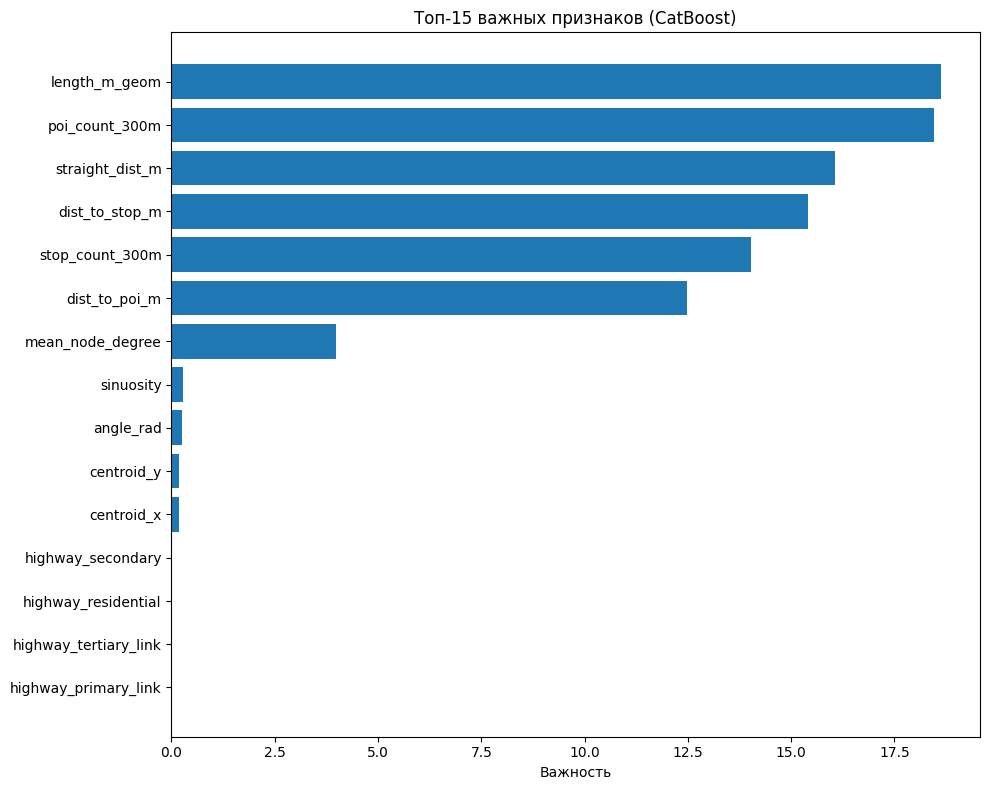


Топ-5 важных признаков:
           feature  importance
0    length_m_geom   18.638512
7   poi_count_300m   18.456337
1  straight_dist_m   16.061150
8   dist_to_stop_m   15.417955
9  stop_count_300m   14.029041


In [18]:
try:
    importances = best_model_tuned.feature_importances_
except AttributeError:
    importances = best_model_tuned.get_feature_importance()

feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title(f'Топ-15 важных признаков ({best_model_name})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nТоп-5 важных признаков:")
print(feature_importance_df.head(5))

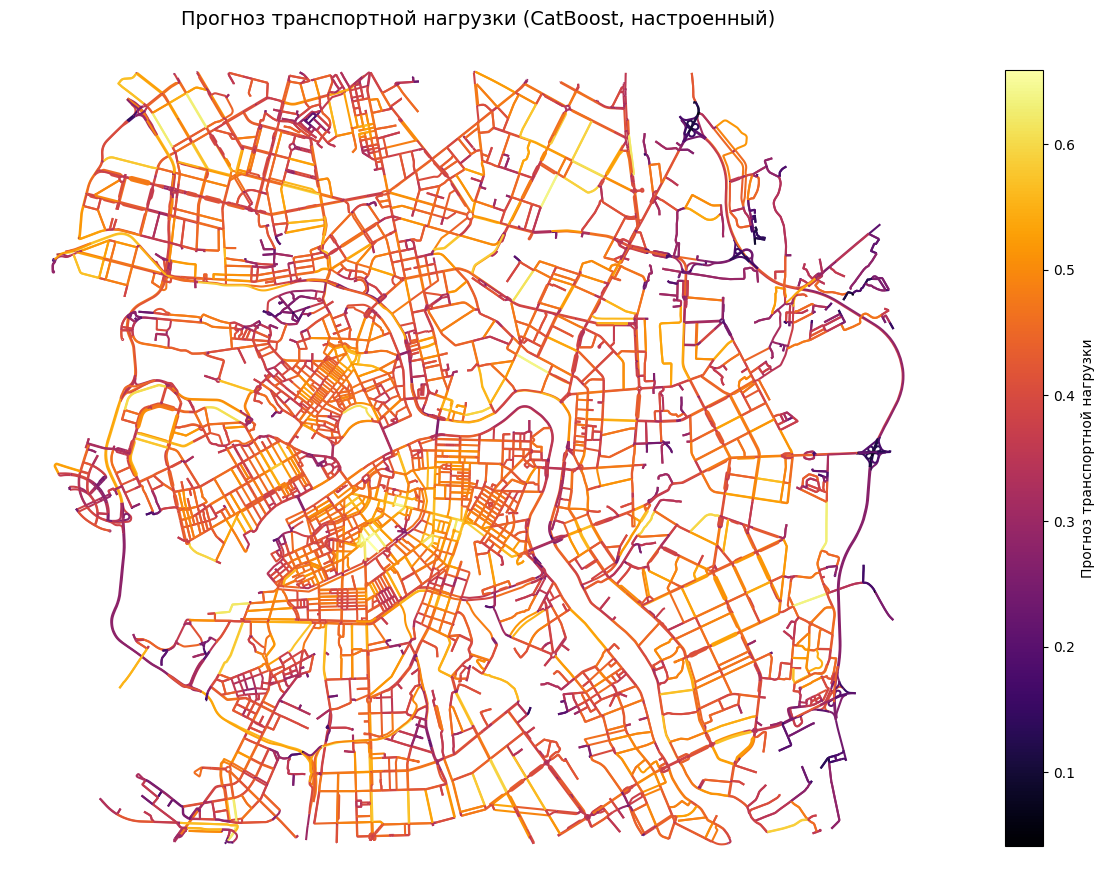

Статистика прогноза:
count    16188.000000
mean         0.388146
std          0.077167
min          0.041300
25%          0.344317
50%          0.388657
75%          0.436776
max          0.658907
Name: predicted_traffic_load, dtype: float64


In [19]:
roads_clean = clean_col_names(roads[feature_cols])
roads["predicted_traffic_load"] = best_model_tuned.predict(roads_clean)
roads_wgs = gpd.GeoDataFrame(roads, geometry="geometry", crs=edges_m.crs).to_crs(4326)

fig, ax = plt.subplots(figsize=(12, 10))
roads_wgs.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.5,
    legend=True,
    cmap="inferno",
    legend_kwds={'label': 'Прогноз транспортной нагрузки', 'shrink': 0.8}
)
ax.set_title(f"Прогноз транспортной нагрузки ({best_model_name}, настроенный)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("Статистика прогноза:")
print(roads["predicted_traffic_load"].describe())